In [5]:
from ultralytics import YOLO
model = YOLO('yolov8m-seg.pt')

In [6]:
results = model('street.jpg')


image 1/1 C:\Users\User\Documents\beersheba-26\back-end\image-processing\street.jpg: 640x512 5 persons, 1 bicycle, 2 cars, 1 handbag, 1 suitcase, 6707.6ms
Speed: 25.9ms preprocess, 6707.6ms inference, 75.7ms postprocess per image at shape (1, 3, 640, 512)


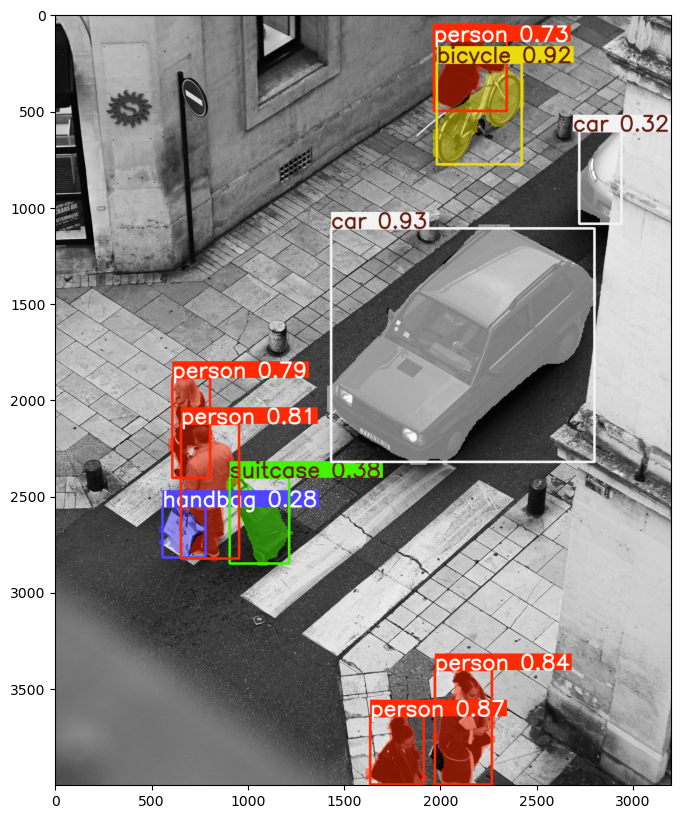

In [24]:
img_annotated = results[0].plot()
import matplotlib.pyplot as plt
plt.figure(figsize=(10, 10))
plt.imshow(img_annotated)
plt.show()

In [9]:
print(results[0].names)

{0: 'person', 1: 'bicycle', 2: 'car', 3: 'motorcycle', 4: 'airplane', 5: 'bus', 6: 'train', 7: 'truck', 8: 'boat', 9: 'traffic light', 10: 'fire hydrant', 11: 'stop sign', 12: 'parking meter', 13: 'bench', 14: 'bird', 15: 'cat', 16: 'dog', 17: 'horse', 18: 'sheep', 19: 'cow', 20: 'elephant', 21: 'bear', 22: 'zebra', 23: 'giraffe', 24: 'backpack', 25: 'umbrella', 26: 'handbag', 27: 'tie', 28: 'suitcase', 29: 'frisbee', 30: 'skis', 31: 'snowboard', 32: 'sports ball', 33: 'kite', 34: 'baseball bat', 35: 'baseball glove', 36: 'skateboard', 37: 'surfboard', 38: 'tennis racket', 39: 'bottle', 40: 'wine glass', 41: 'cup', 42: 'fork', 43: 'knife', 44: 'spoon', 45: 'bowl', 46: 'banana', 47: 'apple', 48: 'sandwich', 49: 'orange', 50: 'broccoli', 51: 'carrot', 52: 'hot dog', 53: 'pizza', 54: 'donut', 55: 'cake', 56: 'chair', 57: 'couch', 58: 'potted plant', 59: 'bed', 60: 'dining table', 61: 'toilet', 62: 'tv', 63: 'laptop', 64: 'mouse', 65: 'remote', 66: 'keyboard', 67: 'cell phone', 68: 'microw

In [11]:
print(results[0].boxes[0])  # Bounding boxes

ultralytics.engine.results.Boxes object with attributes:

cls: tensor([2.])
conf: tensor([0.9276])
data: tensor([[1.4341e+03, 1.1082e+03, 2.8024e+03, 2.3218e+03, 9.2758e-01, 2.0000e+00]])
id: None
is_track: False
orig_shape: (4000, 3200)
shape: torch.Size([1, 6])
xywh: tensor([[2118.2468, 1714.9958, 1368.3212, 1213.5289]])
xywhn: tensor([[0.6620, 0.4287, 0.4276, 0.3034]])
xyxy: tensor([[1434.0863, 1108.2313, 2802.4075, 2321.7603]])
xyxyn: tensor([[0.4482, 0.2771, 0.8758, 0.5804]])


In [ ]:
import pandas as pd 
cls_names = results[0].names
classes = results[0].boxes.cls.cpu().numpy().astype(int)
class_labels = [cls_names[i] for i in classes]
df = pd.DataFrame(results[0].boxes.data.cpu().numpy(), columns=['x1', 'y1', 'x2', 'y2', 'confidence', 'class'   ])
df['class'] = class_labels 
df 

In [23]:
boxes = results[0].boxes
print(boxes)

ultralytics.engine.results.Boxes object with attributes:

cls: tensor([ 2.,  1.,  0.,  0.,  0.,  0.,  0., 28.,  2., 26.])
conf: tensor([0.9276, 0.9248, 0.8670, 0.8364, 0.8103, 0.7878, 0.7264, 0.3751, 0.3233, 0.2810])
data: tensor([[1.4341e+03, 1.1082e+03, 2.8024e+03, 2.3218e+03, 9.2758e-01, 2.0000e+00],
        [1.9836e+03, 2.4779e+02, 2.4243e+03, 7.7511e+02, 9.2483e-01, 1.0000e+00],
        [1.6374e+03, 3.6420e+03, 1.9157e+03, 3.9979e+03, 8.6698e-01, 0.0000e+00],
        [1.9734e+03, 3.4027e+03, 2.2693e+03, 3.9976e+03, 8.3636e-01, 0.0000e+00],
        [6.5449e+02, 2.1233e+03, 9.5626e+02, 2.8234e+03, 8.1034e-01, 0.0000e+00],
        [6.0958e+02, 1.8842e+03, 8.0592e+02, 2.4045e+03, 7.8779e-01, 0.0000e+00],
        [1.9681e+03, 5.2144e+01, 2.3461e+03, 4.9815e+02, 7.2642e-01, 0.0000e+00],
        [9.0774e+02, 2.4037e+03, 1.2167e+03, 2.8500e+03, 3.7508e-01, 2.8000e+01],
        [2.7236e+03, 6.0378e+02, 2.9423e+03, 1.0841e+03, 3.2331e-01, 2.0000e+00],
        [5.5860e+02, 2.5549e+03, 7.8230